In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

# Load data
employee = pd.read_csv('../data/employee_master.csv')
bench = pd.read_csv('../data/bench_allocation.csv')
finance = pd.read_csv('../data/finance_cost.csv')

df = employee.merge(bench, on='employee_id').merge(finance, on='employee_id')

le_dept = LabelEncoder()
le_perf = LabelEncoder()
df['department_enc'] = le_dept.fit_transform(df['department'])
df['performance_enc'] = le_perf.fit_transform(df['performance_rating'])

features = ['bench_days', 'tenure_years', 'salary', 'department_enc', 'performance_enc']
X = df[features]
y = df['attrition_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression (existing)
log_model = LogisticRegression(random_state=42, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]
log_auc = roc_auc_score(y_test, log_prob)

# Model 2: Random Forest (new)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)  # RF doesn't need scaling
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)

print("=== Model Comparison ===")
print(f"Logistic Regression ROC-AUC: {round(log_auc, 3)}")
print(f"Random Forest ROC-AUC:       {round(rf_auc, 3)}")

if rf_auc > log_auc:
    print("\nRandom Forest performs better — selecting it for SHAP analysis.")
    best_model = rf_model
    best_model_name = "Random Forest"
else:
    print("\nLogistic Regression performs better — selecting it for SHAP analysis.")
    best_model = log_model
    best_model_name = "Logistic Regression"

=== Model Comparison ===
Logistic Regression ROC-AUC: 0.638
Random Forest ROC-AUC:       0.567

Logistic Regression performs better — selecting it for SHAP analysis.


c:\Users\ajha1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=800 when initializing the masker.


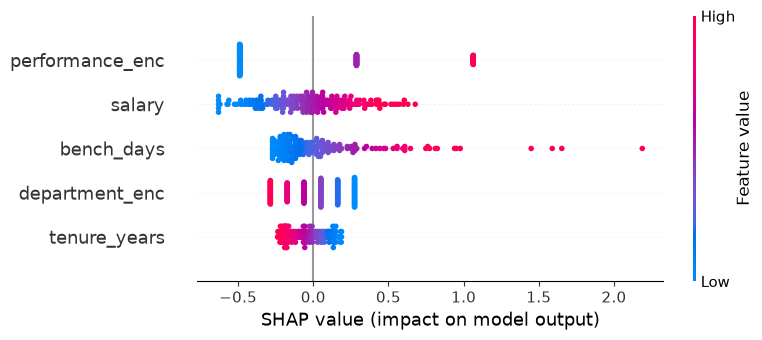

In [2]:
import shap

explainer = shap.LinearExplainer(log_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test, feature_names=features)